# RQ-D7 — mart 분모 축소가 계획된 association 추정에 주는 영향의 상한

**plane D (독립 연구 샌드박스, NON_CANONICAL)** · claim_kind `ANALYSIS`

- 결과 JSON: `research_d/results/RQ_D7_denominator_bounds.json`
- 코드: `research_d/tools/rq_d7_denominator_bounds.py`
- MLflow: `LA_10_RESEARCH_D` / run `e15528648d6d48e0a3cb9bf5afc5139e`
- grain: **target(web_target_group), 모집단 n=59** — step grain 과 섞지 않는다.

이 노트북은 **저장된 JSON 을 다시 쓰지 않는다.** 모듈의 순수 함수만 불러 수치를 재계산하고,
디스크에 있는 JSON 과 대조해 일치를 검증한다.

**방화벽.** `D_INPUT_ALLOWLIST.json` 의 denied 목록을 하나도 열지 않았다. gold label 을
생산하지 않았고, REAL_TARGET 에 접속하지 않았으며(네트워크 사용 없음),
production/control/engine/mart/raw evidence 를 수정하지 않았다(읽기 전용).

**용어 규율.** 이 자료에 '손실' 이라고 부를 것은 없다.
`66→59` 는 결측층이 아니라 반복 실행의 **관측 grain 붕괴**,
`59→56`(3건) 과 `56→31`(25건) 은 원장에 사유가 **기록된 제외**,
56 안의 2건은 mart `measurement_status` 에는 기록되고 원장 outcome 으로는 구별되지 않는 covariate 결측이다.
`prior_*` 는 gold label 이 아니라 **prior** 다.

## 0. 먼저 — 내가 틀리게 틀 잡았다가 raw 확인으로 시정한 것

**틀린 초안 서술.** landing mart 56행 안에서 probe 가 없어 covariate 가 결측인 2 target 을
`UNRECORDED_COVARIATE_MISSING` — *'원장에 사유가 기록돼 있지 않은 결측'* 으로 분류했다.
상위 계층 결함처럼 보이는 서술이었다.

**raw 를 직접 열어 확인.** 보고 전에 collector 원장 `detail.l0` 과 evidence 디렉터리를 열었다.
사유는 **기록돼 있었다** — 기록된 위치가 원장 `outcome` 이 아니라 mart 의 `measurement_status`
와 collector note(`Page.evaluate: Execution context was destroyed`) 였을 뿐이다.
원장 `outcome` 은 `UNRESOLVED` 로 다른 16 target 과 같아 구별이 안 된다.

**시정.** 분류를 `RECORDED_IN_MART_NOT_IN_LEDGER_OUTCOME` 으로 바꾸고 JSON 에
`self_correction` 과 사유 위치 표를 남겼다. 아래 셀에서 그 시정 결과를 직접 확인한다.

시정 과정에서 오히려 진짜로 나온 것 둘: (1) measurement_status 실패 3건 ≠ probe 부재 2건,
(2) probe 없는 2행에서 `max_overlay_coverage` 가 `null` 이 아니라 **`0.0`** 으로 코딩된다
(같은 행 `primary_action_visible_initial` 은 `null` — 한 행 안에서 결측 표현이 불일치).
이것은 `OBSERVATION` 이지 결함 판정이 아니다.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd

RD = Path('/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research'
          '/research/landing_accessibility/research_d')
sys.path.insert(0, str(RD / 'tools'))
import rq_d7_denominator_bounds as R

STORED = json.loads((RD / 'results' / 'RQ_D7_denominator_bounds.json').read_text())
print('stored verdict :', STORED['verdict']['value'])
print('mlflow run_id  :', STORED.get('mlflow_run_id'))
print('hypotheses     :', list(STORED['hypothesis_verdicts']))
CHECKS = []
def check(name, got, exp):
    ok = (got == exp)
    CHECKS.append((name, ok, got, exp))
    print(('  OK  ' if ok else ' MISMATCH ') + f'{name}: recomputed={got} stored={exp}')
    return ok

stored verdict : PARTIALLY_SUPPORTED
mlflow run_id  : e15528648d6d48e0a3cb9bf5afc5139e
hypotheses     : ['H-D7-MCAR', 'H-D7-MAR_OBSERVABLE', 'H-D7-BOUND_UNINFORMATIVE', 'H-D7-BOUND_INFORMATIVE']


In [2]:
# 시정 결과 확인 — L2b 는 '기록 없음' 이 아니라 '원장 outcome 으로 구별 불가' 다
s2b = STORED['denominator_chain']['step_2b_within_mart_covariate_missing']
print('delta_kind      :', s2b['delta_kind'])
print('self_correction :', s2b['self_correction'])
for k, v in s2b['where_the_reason_is_recorded'].items():
    print(f'  {k:48s} -> {v}')
print()
z = STORED['mart_missing_value_coding']
print('measurement_status=FAILED :', z['n_measurement_status_failed'],
      '| 그중 probe 부재:', z['n_of_those_with_probe_absent'],
      '| probe 정상:', z['n_of_those_with_probe_present'])
display(pd.DataFrame(z['rows'])[['wtg','probe_path_is_null','mart_max_overlay_coverage',
                                 'mart_primary_action_visible_initial','ledger_outcome']])
print('내 파싱 결함 배제:', z['parsing_error_ruled_out']['conclusion'])

delta_kind      : RECORDED_IN_MART_NOT_IN_LEDGER_OUTCOME
self_correction : 초안에서 이 2건을 '사유가 기록되지 않은 결측' 이라고 썼다가 raw 를 직접 열어 시정했다. 사유는 기록돼 있다 — 아래 참조.
  fact_landing_observation.measurement_status      -> FAILED_EVIDENCE_INCOMPLETE
  fact_landing_observation.probe_path              -> None
  collector_l0.notes                               -> Error: Page.evaluate: Execution context was destroyed, most likely because of a navigation
  ledger_outcome                                   -> UNRESOLVED — 다른 16 target 과 같은 값이라 원장 outcome 만으로는 이 2건을 구별할 수 없다. 구별은 mart 의 measurement_status 로만 된다.

measurement_status=FAILED : 3 | 그중 probe 부재: 2 | probe 정상: 1


,wtg,probe_path_is_null,mart_max_overlay_coverage,mart_primary_action_visible_initial,ledger_outcome
0,054d78ed187cdd9f,False,0.1137,1.0,UNRESOLVED
1,64d30ef262d8782d,True,0.0000,NaN,UNRESOLVED
2,ef06dc942ef3ccc9,True,0.0000,NaN,UNRESOLVED


내 파싱 결함 배제: 0.0 은 mart 빌더가 만든 값이 아니라 collector 가 이미 0.0 으로 쓴 값이다. 내 파싱 결함이 아니다.


## 1. 분모 사슬 — filesystem · 원장 · mart 세 소스에서 독립 재계산

D 가 확정했다고 한 숫자(66 / 59 / 56 / 31)를 **가설로만 받고** 직접 세어 대조한다.

In [3]:
inputs, obs, landing, task, summary = R.load_inputs()
ledger, ledger_meta = R.load_ledger()
chain = R.denominator_chain(obs, landing, task, summary, ledger)

rows = [
 ('observation dir',        chain['step_0_observation_dirs']['n'], 66),
 ('distinct target (wtg)',  chain['step_1_distinct_targets']['n'], 59),
 ('duplicate launch',       len(chain['step_1_distinct_targets']['duplicate_launch_both_sealed']), 4),
 ('retry 실패',              len(chain['step_1_distinct_targets']['retry_both_empty']), 3),
 ('fact_landing_observation', chain['step_2_landing_mart_rows']['n'], 56),
 ('fact_task_entry target', chain['step_3_task_mart_rows']['distinct_wtg'], 31),
 ('landing 있고 task 없음',  chain['step_3_task_mart_rows']['delta_from_step_2'], 25),
]
display(pd.DataFrame(rows, columns=['단계','내 재계산','D 가설'])
        .assign(일치=lambda d: d['내 재계산'] == d['D 가설']))
print()
print('per_worker dirs :', chain['step_0_observation_dirs']['per_worker'])
print('sealed/empty    :', chain['step_0_observation_dirs']['sealed_dirs'],
      '/', chain['step_0_observation_dirs']['empty_dirs'])
print('집합 정합성     :', chain['set_consistency'])
print()
print('66->59 성격 :', chain['step_1_distinct_targets']['delta_kind'])
print('59->56 성격 :', chain['step_2_landing_mart_rows']['delta_kind'], '| 빠진 wtg:',
      chain['step_2_landing_mart_rows']['excluded_wtg'])
print('   원장 사유 :', chain['step_2_landing_mart_rows']['ledger_reason'])
print('56 안 covariate 결측 wtg :', chain['step_2b_within_mart_covariate_missing']['wtg'])

check('n_targets', chain['step_1_distinct_targets']['n'],
      STORED['denominator_chain']['step_1_distinct_targets']['n'])
check('n_landing', chain['step_2_landing_mart_rows']['n'],
      STORED['denominator_chain']['step_2_landing_mart_rows']['n'])
check('n_task', chain['step_3_task_mart_rows']['distinct_wtg'],
      STORED['denominator_chain']['step_3_task_mart_rows']['distinct_wtg'])
check('excluded_L2_wtg', chain['step_2_landing_mart_rows']['excluded_wtg'],
      STORED['denominator_chain']['step_2_landing_mart_rows']['excluded_wtg'])

,단계,내 재계산,D 가설,일치
0,observation dir,66,66,True
1,distinct target (wtg),59,59,True
2,duplicate launch,4,4,True
3,retry 실패,3,3,True
4,fact_landing_observation,56,56,True
5,fact_task_entry target,31,31,True
6,landing 있고 task 없음,25,25,True



per_worker dirs : {'w01': 15, 'w02': 20, 'w03': 17, 'w04': 14}
sealed/empty    : 60 / 6
집합 정합성     : {'fs_wtg_equals_obs_table_wtg': True, 'fs_wtg_equals_ledger_wtg': True, 'obs_in_mart_flag_equals_landing_set': True}

66->59 성격 : GRAIN_COLLAPSE_NOT_MISSINGNESS
59->56 성격 : LEDGER_RECORDED_EXCLUSION | 빠진 wtg: ['2cd43b99c1ed87cf', 'dd5061eb74e2d4d4', 'ff3ee504792f6cfc']
   원장 사유 : {'2cd43b99c1ed87cf': ['SKIPPED_RETRY_EXHAUSTED'], 'dd5061eb74e2d4d4': ['SKIPPED_RETRY_EXHAUSTED'], 'ff3ee504792f6cfc': ['SKIPPED_RETRY_EXHAUSTED']}
56 안 covariate 결측 wtg : ['64d30ef262d8782d', 'ef06dc942ef3ccc9']
  OK  n_targets: recomputed=59 stored=59
  OK  n_landing: recomputed=56 stored=56
  OK  n_task: recomputed=31 stored=31
  OK  excluded_L2_wtg: recomputed=['2cd43b99c1ed87cf', 'dd5061eb74e2d4d4', 'ff3ee504792f6cfc'] stored=['2cd43b99c1ed87cf', 'dd5061eb74e2d4d4', 'ff3ee504792f6cfc']


True

## 2. 결측 기전 — L3 는 무작위가 아니다 (기전으로는 확정, covariate 검정으로는 미검출)

`fact_task_entry` 행이 없는 25 target 이 원장 `ACCOUNT_ACTION_BLOCKED` 집합과 일치하는지 본다.

In [4]:
f = R.build_frame(obs, landing, task, ledger)
assert len(f) == 59
l3  = set(f.index[(f.has_evidence == 1) & (f.has_task_row == 0)])
aab = set(f.index[f.ledger_account_action_blocked == 1])
print('task row 없음 :', len(l3), '| 원장 ACCOUNT_ACTION_BLOCKED :', len(aab))
print('집합 정확히 일치 :', l3 == aab, '| 대칭차 :', sorted(l3 ^ aab))
print('차단 사유 :', STORED['l3_mechanism_cross_check']['blocked_category_distribution'])
check('l3_exact_set_match', l3 == aab,
      STORED['l3_mechanism_cross_check']['exact_set_match'])

task row 없음 : 25 | 원장 ACCOUNT_ACTION_BLOCKED : 25
집합 정확히 일치 : True | 대칭차 : []
차단 사유 : {'LOGIN': 19, 'PURCHASE': 3, 'SIGNUP': 2, 'PAYMENT': 1}
  OK  l3_exact_set_match: recomputed=True stored=True


True

In [5]:
# covariate 기반 검정은 그 비무작위성을 검출하는가 (BH-FDR)
rng = np.random.default_rng(R.SEED)
d_l3 = R.diagnose_layer(
    f[f.has_evidence == 1].assign(_i=(f[f.has_evidence == 1].has_task_row == 0).astype(int)), '_i',
    'L3', R.BIN_COVS, R.CONT_COVS, R.CAT_COVS, '', rng)
print('L3  검정수', d_l3['n_tests_run'], '| BH q<0.05 통과', d_l3['n_significant_bh05'],
      '| verdict', d_l3['verdict'])
display(pd.DataFrame(d_l3['tests'])[['covariate','kind','stat','p','q_bh','significant_bh05']].head(8))
print('\n기전으로는 100% 결정론적으로 비무작위인데 45개 covariate 검정 중 BH 통과가 0개다.')
print("=> 이 표본에서 '유의한 covariate 가 없다' 를 MCAR 의 증거로 읽으면 안 된다.")
check('L3_n_significant_bh05', d_l3['n_significant_bh05'],
      STORED['missingness_diagnosis']['L3_ledger_recorded_no_task_row']['n_significant_bh05'])
check('L3_n_tests_run', d_l3['n_tests_run'],
      STORED['missingness_diagnosis']['L3_ledger_recorded_no_task_row']['n_tests_run'])

L3  검정수 45 | BH q<0.05 통과 0 | verdict NO_ASSOCIATION_DETECTED_BUT_UNDERPOWERED


,covariate,kind,stat,p,q_bh,significant_bh05
0,cap_any,binary,0.3829,0.00620,0.15300,False
1,cap_count,continuous,0.6662,0.00680,0.15300,False
2,cap_contrast,binary,0.3446,0.01780,0.18428,False
3,cap_accessible_name_sources,binary,0.3459,0.02405,0.18428,False
4,modal_overlay_n,continuous,0.6766,0.02656,0.18428,False
5,dismiss_control_n,continuous,0.6766,0.02656,0.18428,False
6,dom_script_n,continuous,0.6639,0.03689,0.18428,False
7,prior_archetype,categorical,0.4722,0.03755,0.18428,False



기전으로는 100% 결정론적으로 비무작위인데 45개 covariate 검정 중 BH 통과가 0개다.
=> 이 표본에서 '유의한 covariate 가 없다' 를 MCAR 의 증거로 읽으면 안 된다.
  OK  L3_n_significant_bh05: recomputed=0 stored=0
  OK  L3_n_tests_run: recomputed=45 stored=45


True

In [6]:
# 음성 결과도 결과다 — 전체 층 요약
display(pd.DataFrame([
    {'layer': k, 'universe_n': v['universe_n'], 'flagged': v['n_flagged'],
     'tests': v['n_tests_run'], 'sig_BH05': v['n_significant_bh05'], 'verdict': v['verdict']}
    for k, v in STORED['missingness_diagnosis'].items()]))
print('L2b 유의 covariate (flagged n=2 — 취약함):',
      STORED['missingness_diagnosis']['L2b_unrecorded_probe_absent']['significant_covariates'])
print('L2 는 DOM/probe covariate 가 정의상 결측이라 원리적으로 검정 불가 — prior_*/worker 5개만 검정.')

,layer,universe_n,flagged,tests,sig_BH05,verdict
0,L1_dir_grain_excluded_from_mart,66,10,45,0,NO_ASSOCIATION_DETECTED_BUT_UNDERPOWERED
1,L1b_target_grain_duplicate_launch,56,4,45,0,NO_ASSOCIATION_DETECTED_BUT_UNDERPOWERED
2,L2_ledger_recorded_no_evidence,59,3,5,0,NO_ASSOCIATION_DETECTED_BUT_UNDERPOWERED
3,L2b_unrecorded_probe_absent,56,2,20,10,ASSOCIATION_DETECTED
4,L3_ledger_recorded_no_task_row,56,25,45,0,NO_ASSOCIATION_DETECTED_BUT_UNDERPOWERED
5,L2c_measurement_status_failed,56,3,29,0,NO_ASSOCIATION_DETECTED_BUT_UNDERPOWERED


L2b 유의 covariate (flagged n=2 — 취약함): ['dom_body_empty', 'has_l0c', 'dom_bytes', 'ax_bytes', 'css_bytes', 'dom_element_n', 'dom_body_element_n', 'dom_interactive_n', 'dom_script_n', 'dom_body_text_len']
L2 는 DOM/probe covariate 가 정의상 결측이라 원리적으로 검정 불가 — prior_*/worker 5개만 검정.


## 3. Worst-case bound (Manski, 무가정 상한)

추정량은 risk difference `RD = P(Y=1|X=1) − P(Y=1|X=0)`. 결측 배치를 완전열거해 하한·상한을 구한다.
전부 **target grain, n=59**. `fact_task_entry` 는 target 당 1행이므로 target grain 이다.

(a)(b)(c) 는 지정된 후보이고 **(d) 는 내가 추가했다** — (a)(b)(c) 가 전부 L2/L2b 만 결측이라
`56→31` 의 25건이 실제로 무는 곳을 보려면 결과가 task mart 인 association 이 하나 필요했다.

In [7]:
AK = ['a_cap_any_x_commerce','b_modal_x_no_arialabel',
      'c_taskrow_x_password_gate','d_authgate_x_commerce']
tbl = []
for k in AK:
    x, y, meta = R.assoc_vectors(f, k)
    b = R.manski_bounds(x, y)
    cc, wc, su = b['complete_case'], b['worst_case_bound'], b['bound_with_sampling_uncertainty']
    tbl.append({'assoc': k, '결측': b['missing_breakdown']['n_missing_total'],
                'CC RD': cc['risk_difference'],
                'CC 95%': cc['rd_newcombe95'], 'CC 폭': cc['rd_newcombe95_width'],
                '식별구간': [wc['rd_lower'], wc['rd_upper']], '식별폭': wc['rd_width'],
                '부호식별': wc['sign_identified'],
                '+표본오차': [su['rd_lower'], su['rd_upper']], '합산폭': su['rd_width']})
    check(f'bound_width_{k[0]}', wc['rd_width'],
          STORED['bounds'][k]['worst_case_bound']['rd_width'])
    check(f'n_missing_{k[0]}', b['missing_breakdown']['n_missing_total'],
          STORED['bounds'][k]['missing_breakdown']['n_missing_total'])
display(pd.DataFrame(tbl))

  OK  bound_width_a: recomputed=0.1597 stored=0.1597
  OK  n_missing_a: recomputed=5 stored=5
  OK  bound_width_b: recomputed=0.2943 stored=0.2943
  OK  n_missing_b: recomputed=5 stored=5
  OK  bound_width_c: recomputed=0.5138 stored=0.5138
  OK  n_missing_c: recomputed=5 stored=5
  OK  bound_width_d: recomputed=0.9301 stored=0.9301
  OK  n_missing_d: recomputed=28 stored=28


,assoc,결측,CC RD,CC 95%,CC 폭,식별구간,식별폭,부호식별,+표본오차,합산폭
0,a_cap_any_x_commerce,5,0.3366,"[0.1004, 0.5376]",0.4372,"[0.211, 0.3706]",0.1597,True,"[-0.0245, 0.5639]",0.5884
1,b_modal_x_no_arialabel,5,0.0000,"[-0.1759, 0.0964]",0.2723,"[-0.2174, 0.0769]",0.2943,False,"[-0.419, 0.2032]",0.6222
2,c_taskrow_x_password_gate,5,0.1373,"[-0.3398, 0.4404]",0.7802,"[-0.2138, 0.3]",0.5138,False,"[-0.482, 0.5084]",0.9904
3,d_authgate_x_commerce,28,0.0333,"[-0.2865, 0.3435]",0.6300,"[-0.4499, 0.4802]",0.9301,False,"[-0.6326, 0.6576]",1.2901


In [8]:
print('폭을 직접 비교하지 마라 — 서로 다른 종류의 불확실성이다.')
print(' (a) 식별구간 0.160 < CC CI 0.437 인 것은 모순이 아니다: 식별구간에는 표본오차가 없다.')
print()
sc = STORED['hypothesis_verdicts']['H-D7-BOUND_INFORMATIVE']['sharpest_case']
print('가장 날카로운 사례 —', sc['association'])
print('  complete-case 95% :', sc['complete_case_newcombe95'], '-> 0 배제')
print('  식별구간          :', sc['identification_bound'], '-> 0 배제')
print('  둘을 합치면       :', sc['bound_plus_sampling'], '-> 0 배제 못 함')
print(' ', sc['reading'])

폭을 직접 비교하지 마라 — 서로 다른 종류의 불확실성이다.
 (a) 식별구간 0.160 < CC CI 0.437 인 것은 모순이 아니다: 식별구간에는 표본오차가 없다.

가장 날카로운 사례 — a_cap_any_x_commerce
  complete-case 95% : [0.1004, 0.5376] -> 0 배제
  식별구간          : [0.211, 0.3706] -> 0 배제
  둘을 합치면       : [-0.0245, 0.5639] -> 0 배제 못 함
  complete-case CI 는 0 을 배제하고 식별구간도 0 을 배제하지만, 둘을 합치면 0 을 배제하지 못한다. 이 association 을 깨는 것은 25건이 아니라 5건이다.


## 4. 층별 기여 분해 — "3건만 복구하면 되는가, 25건이 문제인가"

**둘 다 답이 아니다. association 이 어느 mart 를 결과로 쓰는지에 달렸다.**

주의: 여기서 '복구' 는 반사실이다 — 해당 층의 결측을 complete-case 조건부 비율로 채운 것이다.
bound **폭**은 남은 결측 수에 지배돼 채움값에 사실상 무관하지만 **중심**은 채움값에 의존한다.
**폭만 해석하라.**

In [9]:
SC = ['S0_nothing_recovered','S_L2_ledger_recorded_no_evidence_only',
      'S_L2b_unrecorded_probe_absent_only','S_L3_ledger_recorded_no_task_row_only',
      'S_all_recovered']
rows = []
for k in AK:
    dec = R.layer_decomposition(f, k)
    r = {'assoc': k}
    for s in SC:
        r[s.replace('S_','').replace('_only','').replace('_ledger_recorded','')[:18]] = \
            dec['scenarios'][s]['rd_width']
    r['지배층'] = dec['dominant_layer'].replace('S_','').replace('_only','')
    rows.append(r)
    check(f'decomp_S0_{k[0]}', dec['scenarios']['S0_nothing_recovered']['rd_width'],
          STORED['layer_decomposition']['per_association'][k]['scenarios']
                ['S0_nothing_recovered']['rd_width'])
display(pd.DataFrame(rows))
print()
print(STORED['layer_decomposition']['answer_3_vs_25'])

  OK  decomp_S0_a: recomputed=0.1597 stored=0.1597
  OK  decomp_S0_b: recomputed=0.2943 stored=0.2943
  OK  decomp_S0_c: recomputed=0.5138 stored=0.5138
  OK  decomp_S0_d: recomputed=0.9301 stored=0.9301


,assoc,S0_nothing_recover,L2_no_evidence,L2b_unrecorded_pro,L3_no_task_row,all_recovered,지배층
0,a_cap_any_x_commerce,0.1597,0.0688,0.0909,0.1597,0.0,L2_ledger_recorded_no_evidence
1,b_modal_x_no_arialabel,0.2943,0.0870,0.2074,0.2943,0.0,L2_ledger_recorded_no_evidence
2,c_taskrow_x_password_gate,0.5138,0.1844,0.3294,0.5138,0.0,L2_ledger_recorded_no_evidence
3,d_authgate_x_commerce,0.9301,0.8392,0.9301,0.0909,0.0,L3_ledger_recorded_no_task_row



둘 다 답이 아니고 association 이 어느 mart 를 결과로 쓰는지에 달렸다. 결과가 landing mart 인 association((a)(b)(c))은 결측이 3~5건뿐이라 25건 복구는 bound 를 전혀 좁히지 못한다. 결과가 task mart 인 association((d))은 25건이 결측의 89%(25/28)를 차지해 3건만 복구해도 폭이 거의 그대로다.


In [10]:
# 66->59 층의 기여는 0 인가 — canonical dir 선택이 bound 변수를 뒤집는가
amb = R.l1_canonical_ambiguity(obs)
print('중복발사 target 검사 :', amb['n_duplicate_launch_targets_checked'])
print('bound 변수 뒤집힘    :', amb['n_with_bound_variable_flip'])
print(amb['contribution_to_bound_width'])
print()
print('연속값은 흔들린다 — 예: 13ed070478ef62c3 의 modal_overlay_n =',
      amb['per_target']['13ed070478ef62c3']['modal_overlay_n']['values'],
      '| 이진화 후 뒤집힘 :',
      amb['per_target']['13ed070478ef62c3']['derived_binary_flips'])
check('l1_flips', amb['n_with_bound_variable_flip'],
      STORED['layer_decomposition']['l1_canonical_choice_ambiguity']['n_with_bound_variable_flip'])

중복발사 target 검사 : 4
bound 변수 뒤집힘    : 0
0 — canonical dir 선택은 본 RQ 의 bound 변수 4개 중 어느 것도 뒤집지 않는다

연속값은 흔들린다 — 예: 13ed070478ef62c3 의 modal_overlay_n = [6.0, 7.0] | 이진화 후 뒤집힘 : {'X_b_aria0': False, 'Y_b_modal_gt0': False, 'X_c_password_gt0': False, 'Y_a_cap_any': False}
  OK  l1_flips: recomputed=0 stored=0


True

## 5. 그림

figures/RQ_D7_bounds_vs_cc.png


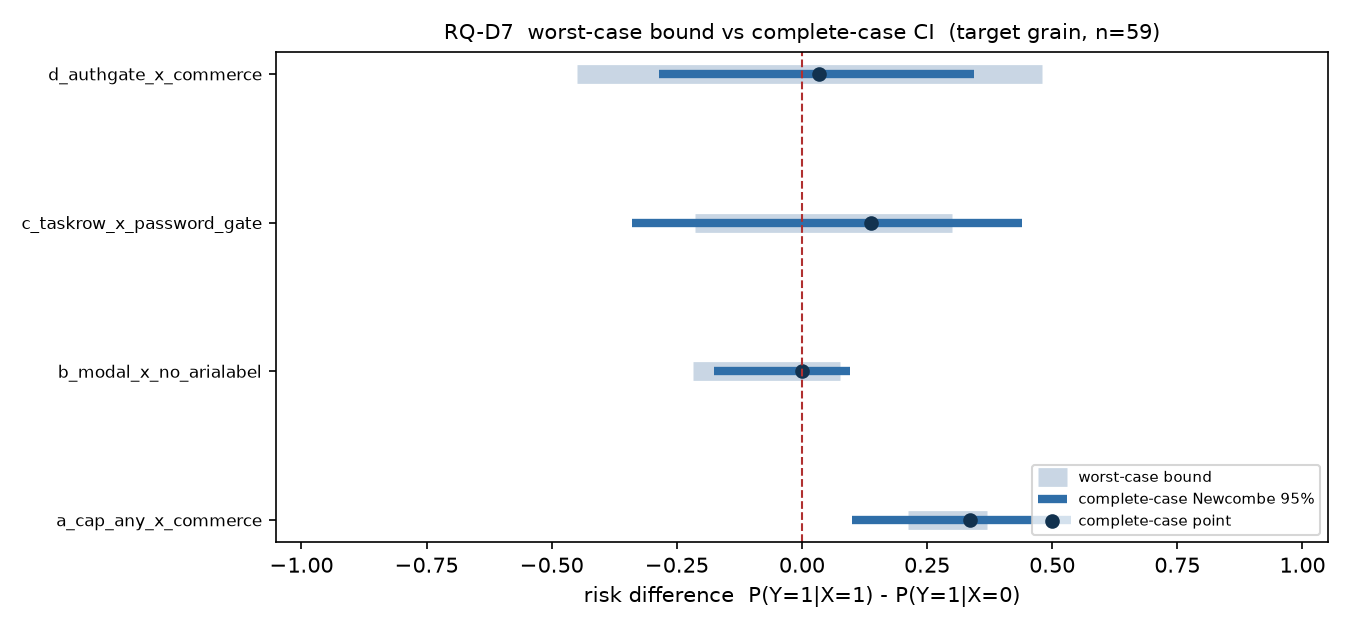

figures/RQ_D7_layer_decomposition.png


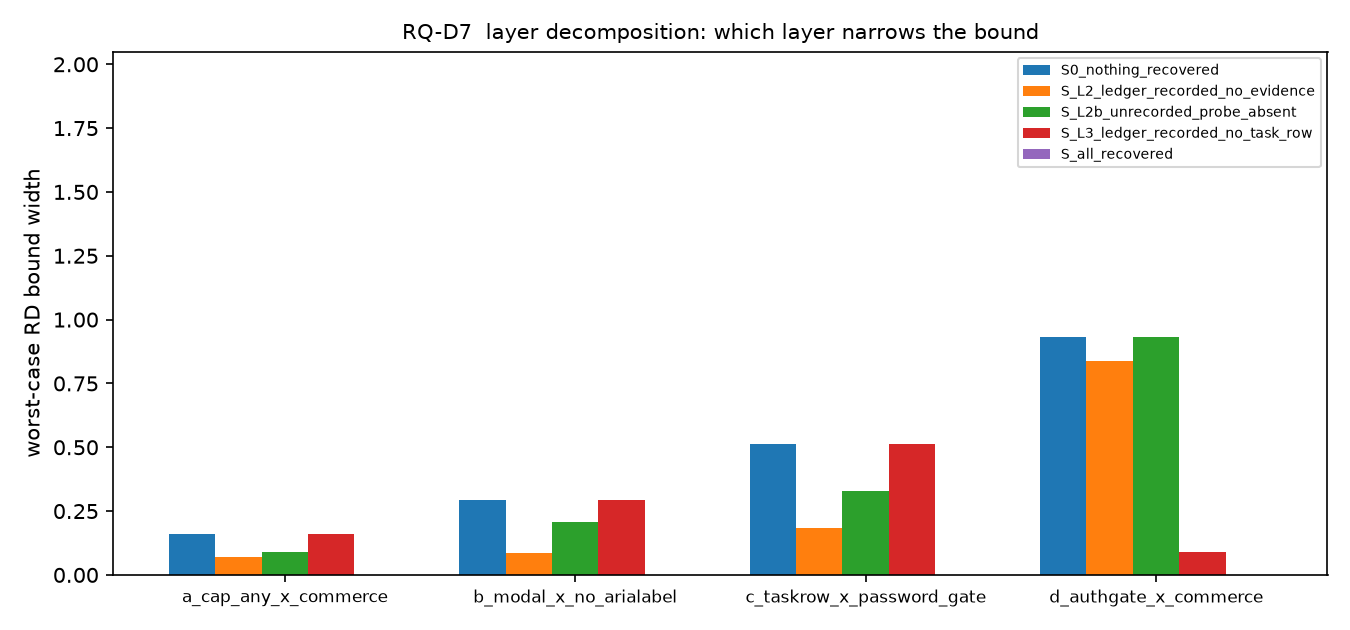

In [11]:
from IPython.display import Image, display as disp
for p in ['figures/RQ_D7_bounds_vs_cc.png', 'figures/RQ_D7_layer_decomposition.png']:
    print(p); disp(Image(filename=str(RD / p)))

## 6. 경쟁가설 판정 · 반례 · 이 RQ 가 답하지 않는 것

In [12]:
for h, v in STORED['hypothesis_verdicts'].items():
    print(f'{h:28s} -> {v["verdict"]}')
print()
print('반례 (내 결론에 불리한 것):')
for k, v in STORED['counterexamples'].items():
    print(' -', k, ':', (v if isinstance(v, str) else json.dumps(v, ensure_ascii=False))[:180])
print()
print('이 RQ 가 답하지 않는 것:')
print(' ', STORED['not_answered_by_this_rq'])
print()
print('가장 무거운 limitation:')
print(' ', STORED['limitation'][0])

H-D7-MCAR                    -> REFUTED_ON_MECHANISM_NOT_DETECTED_BY_COVARIATE_TESTS
H-D7-MAR_OBSERVABLE          -> PARTIALLY_SUPPORTED
H-D7-BOUND_UNINFORMATIVE     -> SUPPORTED_ONLY_WHERE_THE_OUTCOME_LIVES_IN_THE_TASK_MART
H-D7-BOUND_INFORMATIVE       -> SUPPORTED_FOR_IDENTIFICATION_REGION_ONLY

반례 (내 결론에 불리한 것):
 - against_bound_uninformative : [{"association": "a_cap_any_x_commerce", "rd_bound": [0.211, 0.3706], "note": "결측 3~5건에서는 worst-case 여도 부호가 식별될 수 있다"}]
 - against_mcar_being_testable : L2 의 3 target 은 DOM/probe covariate 가 정의상 결측이라, 그 covariate 들과의 연관을 검정할 방법이 없다. 검정 결과가 음성인 것이 MCAR 의 증거가 아니다.
 - against_treating_L1_as_missingness : 중복발사 4 target 에서 canonical dir 을 바꿔도 본 RQ 의 bound 변수는 0건에서만 뒤집힌다 — 66->59 는 분모 문제가 아니다.

이 RQ 가 답하지 않는 것:
  이 bound 폭이 계획된 분석에 충분한지, 무엇을 다시 모을지, 어떤 분모를 공식 분모로 삼을지는 답하지 않는다 — construct 와 결정은 A 권한이다.

가장 무거운 limitation:
  층별 분해에서 '복구' 는 해당 층의 결측을 complete-case 조건부 비율로 결정론적으로 채운 것이다. bound **폭** 은 남은 결측 수에 지배돼 이 채움값에 사실상 무관하지만 bound **중심** 은 채움값에 의

## 7. 재계산 ↔ 저장된 JSON 대조 결과

In [13]:
bad = [c for c in CHECKS if not c[1]]
print(f'대조 항목 {len(CHECKS)}개 · 불일치 {len(bad)}개')
for name, ok, got, exp in bad:
    print('  MISMATCH', name, got, exp)
assert not bad, f'저장된 JSON 과 재계산이 불일치: {[b[0] for b in bad]}'
print('\n노트북 재계산이 저장된 JSON 과 전부 일치한다.')
print('MLflow run_id :', STORED['mlflow_run_id'])

대조 항목 20개 · 불일치 0개

노트북 재계산이 저장된 JSON 과 전부 일치한다.
MLflow run_id : e15528648d6d48e0a3cb9bf5afc5139e
